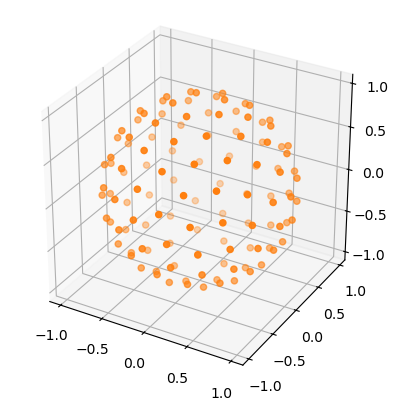

In [6]:
#
# Emre Alca
# University of Pennsylvania
# Created on Tue Mar 17 2026
#

import numpy as np
import trimesh
import matplotlib.pyplot as plt
N = 130 # number of boundary points
R = 1 # radius of sphere
sphere_lattice = np.load(f"/Users/emrealca/Documents/Penn/flatiron-microtubules/simulations/data/sloane_cache/sloane_{N}.npy")

# sphere_lattice = np.array([
#     [1, 0, 0],
#     [-1, 0, 0],
#     [0, 1, 0],
#     [0, -1, 0],
#     [0, 0, 1],
#     [0, 0, -1],
# ])

# -- thousands of MTs-- 
# boundary = trimesh.creation.icosphere(subdivisions=6, radius=1) # initializes discretized boundary boundary condition
# boundary_sites = np.array(boundary.vertices) 
# sphere_lattice = boundary_sites
# N = boundary_sites.shape[0]
# print(N)

# -- 3d scatterplot -- 
xs = sphere_lattice[:,0]
ys = sphere_lattice[:,1]
zs = sphere_lattice[:,2]
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(xs,ys,zs, c='tab:orange')
ax.set_aspect('equal', 'box')
plt.show()

## linear stability analysis on 3-D pushing only centrosomal centring without turnover (mechanics only)


We start with the equations of motion.
We have an MTOC at $r(t) = x \hat{x} + y \hat{y} + z \hat{z}$.
We have some set of MTs which impinge on the boundary at the positions $\{\vec{B}_i \}$
The equations of motion of this system are then
$$
    \dot{\vec{r}} = - \frac{ \pi^2 \kappa}{\eta} \sum_i \frac{\hat{m}_i}{l_i^2} = - \frac{ \pi^2 \kappa}{\eta} \sum_i \frac{\vec{B}_i - \vec{r}(t)}{||\vec{B}_i-  \vec{r}(t)||^3}
$$

Define $\vec{u}(t) = \vec{B}_i - \vec{r}(t)$ so we have 
$$
    \dot{\vec{r}} = - \frac{ \pi^2 \kappa}{\eta} \sum_i \frac{\vec{u}_i}{||\vec{u}_i||^3}
$$

To perform linear stability analysis, we need to take the Jacobian of this system at $\vec{r}=\vec{0}$.

for any vector $\vec{n}$
$$
    \begin{align}
    \frac{\partial}{\partial \vec{n}} \left( \vec{n} \cdot ||\vec{n}||^{-3} \right) &= \left( \frac{\partial}{\partial \vec{n}} \vec{n} \right) ||\vec{n}||^{-3} + \vec{n} \left( \frac{\partial}{\partial \vec{n}} ||\vec{n}||^{-3} \right)^T \\
    & = \frac{\mathbb{I}}{||\vec{n}||^{3}} -\frac{3\vec{n}}{|| \vec{n}||^{4}} \hat{n}^T \\
    & = \frac{\mathbb{I} - 3 \hat{n} \hat{n}^T}{||\vec{n}||^3}
    \end{align}
$$

now we substitute this result back into our jacobian and find 
$$
    J = \frac{\partial \dot{\vec{r}}}{\partial \vec{r}} = \frac{ \pi^2 \kappa}{\eta} \sum_i \frac{\mathbb{I} - 3 \hat{u}_i \hat{u}_i^T}{||\vec{u}_i||^3}
$$
note that I have dropped the minus sign as $\partial \vec{u}_i / \partial \vec{u}_i = - \mathbb{I}$ from the dependence on $- \vec{r}$, which would appear in both terms.

When $\vec{r}_* = \vec{0}$, $\vec{u}_i = \vec{B}_i$
If we are working on the unit sphere $|| \vec{B}_i || = 1$ and $\hat{B}_i = \vec{B_i}$, making our Jacobian
$$
    J = \frac{ \pi^2 \kappa}{\eta} \sum_i (\mathbb{I} - 3\vec{B}_i \vec{B}_i^T)
$$
Let's calculate this jacobian

In [2]:

rigidity = 1
drag_coefficient = 100

prefactor = (np.square(np.pi) * rigidity) / drag_coefficient

jacobian = np.zeros((3,3))

for boundary_point in sphere_lattice:
    jacobian += np.eye(3) -  (3 * np.outer(boundary_point, boundary_point))

jacobian = prefactor * jacobian

print(f'Jacobian:\n{jacobian}')

eigenvalues, eigenvectors = np.linalg.eig(jacobian) 
print(f'eigenvalues: \n{eigenvalues}')   

Jacobian:
[[-3.19081295e-12  3.88989903e-15 -6.02468657e-14]
 [ 3.88989903e-15 -4.73002956e-12  6.98366995e-16]
 [-6.02468657e-14  6.98366995e-16  2.19721221e-12]]
eigenvalues: 
[ 2.19788584e-12 -3.19147665e-12 -4.73003949e-12]


Analytically, for the 6 MT octahedron case, the eigenvalues evaluate to zero exactly. For other cases, we can already see that we have a saddle point (though very small. $> 10^{-10}$).
This is unsurprising, since the lengths of all MTs are the same at this point. the affects of the length dependence necessarily do not appear.

For more symmetric cases, we can see the saddle behaviour when we look at a small deviation from the origin. That way, we can see the length dependence come into play.

Set $\vec{r} = \vec{\delta}$ where $||\vec{\delta}||$ is small and then we have $\vec{u}_i = \vec{B}_i - \vec{\delta}$
And once again we will calculate 
$$
J = \frac{ \pi^2 \kappa}{\eta} \sum_i \frac{(\mathbb{I} - \hat{u}_i \hat{u}_i^T)}{||\vec{u}_i||}
$$

In [3]:
delta = np.ones(3) * 1e-6
# delta = np.array([0.001, 0, 0])

jacobian_perturbed = np.zeros((3,3))

for boundary_point in sphere_lattice:
    ui = boundary_point - delta
    norm_ui = np.linalg.norm(ui)
    ui_hat = ui / norm_ui

    jacobian_perturbed += (np.eye(3) -  (3 * np.outer(ui_hat, ui_hat))) / (norm_ui ** 3)

jacobian_perturbed = prefactor * jacobian_perturbed
print(f'perturbed Jacobian:\n{jacobian_perturbed}')

eigenvalues, eigenvectors = np.linalg.eig(jacobian_perturbed) 
print(f'perturbed eigenvalues: \n{eigenvalues}')   

perturbed Jacobian:
[[-3.01871505e-12  2.18042537e-13 -2.79817147e-12]
 [ 2.18042537e-13  5.32171059e-13 -3.08375512e-14]
 [-2.79817147e-12 -3.08375512e-14  1.35713646e-12]]
perturbed eigenvalues: 
[-4.38956907e-12  2.72815564e-12  5.32005904e-13]


I've looked through a number of sets of MTs with uniform distributions on the sphere (up to 130 MTs) and all of them have one or two negative eigenvalues, but never 3.

Let's try them all:

In [4]:
def linear_stability_analysis(N, delta):
    # print(f'number of MTs: {N}')
    rigidity = 1
    drag_coefficient = 100
    prefactor = (np.square(np.pi) * rigidity) / drag_coefficient

    sphere_lattice = np.load(f"/Users/emrealca/Documents/Penn/flatiron-microtubules/simulations/data/sloane_cache/sloane_{N}.npy")
    delta = np.ones(3) * 1e-6

    jacobian_perturbed = np.zeros((3,3))

    for boundary_point in sphere_lattice:
        ui = boundary_point - delta
        norm_ui = np.linalg.norm(ui)
        ui_hat = ui / norm_ui

        jacobian_perturbed += (np.eye(3) -  (3 * np.outer(ui_hat, ui_hat))) / (norm_ui ** 3)

    jacobian_perturbed = prefactor * jacobian_perturbed
    # print(f'perturbed Jacobian:\n{jacobian_perturbed}')

    eigenvalues, eigenvectors = np.linalg.eig(jacobian_perturbed) 
    # print(f'perturbed eigenvalues: \n{eigenvalues}') 
    return eigenvalues

# delta = np.array([1e-3, 0,0])
delta = np.ones(3) * 1e-6
all_saddle = True
for n in np.arange(4, 131):
    eigenvalues = linear_stability_analysis(n, delta)
    if (eigenvalues < 0).all():
        print(f'found a stable confirmation with {n} points')
        all_saddle = False
    if (eigenvalues > 0).all():
        print(f'found a unstable confirmation with {n} points')
        all_saddle = False

print(f'all confirmations where saddles: {all_saddle}') 

all confirmations where saddles: True
